<a href="https://colab.research.google.com/github/JosephNathaniel/ARENA/blob/main/chapter1_transformer_interp/exercises/part2_intro_to_mech_interp/induction-heads-rigorously.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [21]:
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import math
import einops
import matplotlib.pyplot as plt

# Part 1 -- a minimal, analytic induction head

## Model

In [15]:
class AttentionBlock(nn.Module):
    """
    A single attention block according to the specified constraints:
    - 1 head
    - d_head = d_model
    - No MLP block
    - No LayerNorm
    - Positional embeddings added to Q and K inputs, not the residual stream.
    """
    def __init__(self, d_model: int, max_seq_len: int):
        super().__init__()
        self.d_model = d_model
        # Since num_heads = 1 and d_head = d_model, these are square matrices
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        # Scale factor for attention
        self.scale = d_model ** -0.5


    def forward(self, x: t.Tensor, pos_emb: t.Tensor, mask: t.Tensor | None = None) -> t.Tensor:
        """
        Forward pass for the Attention Block.

        Args:
            x: Input tensor (residual stream). Shape: (batch_size, seq_len, d_model)
            pos_emb: Positional embeddings. Shape: (1, seq_len, d_model) or (batch_size, seq_len, d_model)
            mask: Optional attention mask. Shape: (batch_size, seq_len, seq_len) or similar broadcastable.
                  Positions with `False` or `0` will be masked out.

        Returns:
            Output tensor after attention and output projection. Shape: (batch_size, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape

        # 1. Add positional embeddings *before* Q and K projections
        #    Value stream does not get positional embeddings.
        qk_input = x + pos_emb
        v_input = x # V uses the original residual stream state

        # 2. Project inputs to Q, K, V
        Q = self.W_q(qk_input) # Shape: (batch_size, seq_len, d_model)
        K = self.W_k(qk_input) # Shape: (batch_size, seq_len, d_model)
        V = self.W_v(v_input) # Shape: (batch_size, seq_len, d_model)

        # 3. Calculate scaled dot-product attention scores
        # (batch, seq_len, d_model) @ (batch, d_model, seq_len) -> (batch, seq_len, seq_len)
        attn_scores = einops.einsum(Q, K, "b sq d, b sk d -> b sq sk") * self.scale

        # 4. Apply attention mask (if provided)
        if mask is not None:
            if mask.dim() == 3:
                 mask = mask[:,:seq_len, :seq_len] # this will deal with overly-large causal mask
            else:
                 raise NotImplementedError

            # Masked positions (False) are filled with a large negative value
            attn_scores = attn_scores.masked_fill(mask == False, -1e9) # Use a large negative number

        # 5. Apply softmax to get attention probabilities
        attn_probs = F.softmax(attn_scores, dim=-1) # Shape: (batch_size, seq_len, seq_len)

        # 6. Calculate weighted sum of Values
        # (batch, seq_len, seq_len) @ (batch, seq_len, d_model) -> (batch, seq_len, d_model)
        attn_output = einops.einsum(attn_probs, V, "b sq sk, b sk d -> b sq d")

        # 7. Apply output projection
        output = self.W_o(attn_output) # Shape: (batch_size, seq_len, d_model)

        return output


class SimpleTransformer(nn.Module):
    """
    A simple 2-layer, attention-only Transformer with a specific positional embedding handling.
    """
    def __init__(self, vocab_size: int, d_model: int, num_layers: int, max_seq_len: int):
        super().__init__()
        assert num_layers == 2, "This specific implementation is hardcoded for num_layers=2"
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Token Embedding layer
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Positional Embedding layer (will be added before Q and K, not to residual stream directly)
        self.positional_embedding = nn.Embedding(max_seq_len, d_model)

        # Stack of Attention Blocks
        self.layers = nn.ModuleList([AttentionBlock(d_model, max_seq_len) for _ in range(num_layers)])

        # Final linear layer to map back to vocabulary size (optional, for tasks like LM)
        self.unembed = nn.Linear(d_model, vocab_size, bias=False)

        # Create maximally sized causal mask. Shape (1, max_seq_len, max_seq_len)
        # False is masked, True is unmasked
        self.maximal_causal_mask = t.tril(t.ones(1,max_seq_len, max_seq_len), diagonal=-1).bool()

    def forward(self, input_ids: t.Tensor, attention_mask: t.Tensor | None = None) -> t.Tensor:
        """
        Forward pass for the Simple Transformer.

        Args:
            input_ids: Input token IDs. Shape: (batch_size, seq_len)
            attention_mask: Optional mask to prevent attention to certain positions (e.g., padding).
                            Positions that are True are kept, False are masked.
                            Can handle overly large masks, various number of dimensions...
                            Will be converted to the appropriate shape for attention scores.

        Returns:
            Logits tensor. Shape: (batch_size, seq_len, vocab_size)
        """
        batch_size, seq_len = input_ids.shape
        if seq_len > self.max_seq_len:
             raise ValueError(f"Input sequence length ({seq_len}) exceeds model's max sequence length ({self.max_seq_len})")


        # 1. Get Token Embeddings
        token_emb = self.token_embedding(input_ids) # Shape: (batch_size, seq_len, d_model)

        # 2. Get Positional Embeddings
        # Create position IDs (0, 1, 2, ..., seq_len-1)
        position_ids = t.arange(0, seq_len, device=input_ids.device).unsqueeze(0) # Shape: (1, seq_len)
        pos_emb = self.positional_embedding(position_ids) # Shape: (1, seq_len, d_model)
        # pos_emb will broadcast correctly to (batch_size, seq_len, d_model) when added

        # Initial residual stream is just the token embeddings
        residual_stream = token_emb

        for layer in self.layers:
            # Pass the current residual stream and the *same* positional embeddings each time
            attn_output = layer(residual_stream, pos_emb, mask=attention_mask)
            # Add the output of the attention block back to the residual stream
            residual_stream = residual_stream + attn_output

        # 5. Final unembedding layer (optional)
        logits = self.unembed(residual_stream) # Shape: (batch_size, seq_len, vocab_size)

        return logits

## Example Usage

In [42]:
# Configuration
VOCAB_SIZE = 20
D_MODEL = 128
NUM_LAYERS = 2 # As requested
MAX_SEQ_LEN = 64
BATCH_SIZE = 4
DEVICE = "cuda" if t.cuda.is_available() else "cpu"

In [17]:
# Generate induction head behaviour dataset

def generate_repeated_tokens(
    vocab_size, seq_len: int, batch_size: int = 1
) -> t.Tensor: # batch_size 2*seq_len
    """
    Generates a sequence of repeated random tokens

    Outputs are:
        rep_tokens: [batch_size, 1+2*seq_len]
    """
    rand_seq = t.randint(low=0, high=vocab_size, size=(batch_size, seq_len)).to(DEVICE)
    return_tensor = t.concat([rand_seq, rand_seq], dim=1) # NOTE tokenizer bos token id accessible
    return return_tensor

In [18]:
test_sequences = generate_repeated_tokens(VOCAB_SIZE, 20, BATCH_SIZE)
print(test_sequences)

tensor([[507, 411, 523, 239, 325, 720, 768, 949, 730, 805, 791, 233, 891, 447,
         934, 251, 784,  71, 260, 538, 507, 411, 523, 239, 325, 720, 768, 949,
         730, 805, 791, 233, 891, 447, 934, 251, 784,  71, 260, 538],
        [522, 718, 893, 693, 734, 820, 897, 109, 250, 471, 746,  89, 908, 353,
         541, 472, 360, 888,  48, 625, 522, 718, 893, 693, 734, 820, 897, 109,
         250, 471, 746,  89, 908, 353, 541, 472, 360, 888,  48, 625],
        [293, 956, 209, 318, 445,  47,  16, 360, 718, 480, 333, 639, 431,  26,
         668,  49,  90, 778, 327, 957, 293, 956, 209, 318, 445,  47,  16, 360,
         718, 480, 333, 639, 431,  26, 668,  49,  90, 778, 327, 957],
        [535, 285, 999, 554, 704, 345,  78, 207, 474, 749, 534, 439,  93, 207,
         208, 474, 824, 137, 383, 322, 535, 285, 999, 554, 704, 345,  78, 207,
         474, 749, 534, 439,  93, 207, 208, 474, 824, 137, 383, 322]])


In [19]:
# Instantiate the model
model = SimpleTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)
model.to(DEVICE)

print(f"Model:\n{model}")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {num_params:,}")

Model:
SimpleTransformer(
  (token_embedding): Embedding(1000, 128)
  (positional_embedding): Embedding(64, 128)
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (W_q): Linear(in_features=128, out_features=128, bias=False)
      (W_k): Linear(in_features=128, out_features=128, bias=False)
      (W_v): Linear(in_features=128, out_features=128, bias=False)
      (W_o): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (unembed): Linear(in_features=128, out_features=1000, bias=False)
)

Total trainable parameters: 395,264


In [20]:
# Perform a forward pass
try:
    with t.no_grad(): # Disable gradient calculations for inference
        output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask)

    print(f"\nInput shape: {test_sequences.shape}")
    print(f"Attention mask shape: {model.maximal_causal_mask.shape}")
    print(f"Output logits shape: {output_logits.shape}")
    print("\nForward pass successful!")

    # # Verify masking (optional check)
    # # Create a fully masked input and check if output changes significantly for masked parts
    # masked_input = t.randint(0, VOCAB_SIZE, (1, SEQ_LEN))
    # full_mask = t.zeros(1, SEQ_LEN)
    # out_fully_masked = model(masked_input, attention_mask=full_mask)
    # out_no_mask = model(masked_input, attention_mask=t.ones(1,SEQ_LEN))
    # # This is a basic check; rigorous checks would involve inspecting attention scores.
    # print(f"Output norm with no mask: {t.norm(out_no_mask)}")
    # print(f"Output norm with full mask: {t.norm(out_fully_masked)} (should be similar if initial embedding dominates)")

except Exception as e:
    print(f"\nAn error occurred during forward pass: {e}")
    import traceback
    traceback.print_exc()


# Example with sequence length exceeding max_seq_len
print("\nTesting sequence length > max_seq_len:")
long_input_ids = t.randint(0, VOCAB_SIZE, (BATCH_SIZE, MAX_SEQ_LEN + 1))
try:
      with t.no_grad():
          output_logits = model(long_input_ids)
except ValueError as e:
      print(f"Caught expected error: {e}")


Input shape: torch.Size([4, 40])
Attention mask shape: torch.Size([1, 64, 64])
Output logits shape: torch.Size([4, 40, 1000])

Forward pass successful!

Testing sequence length > max_seq_len:
Caught expected error: Input sequence length (65) exceeds model's max sequence length (64)


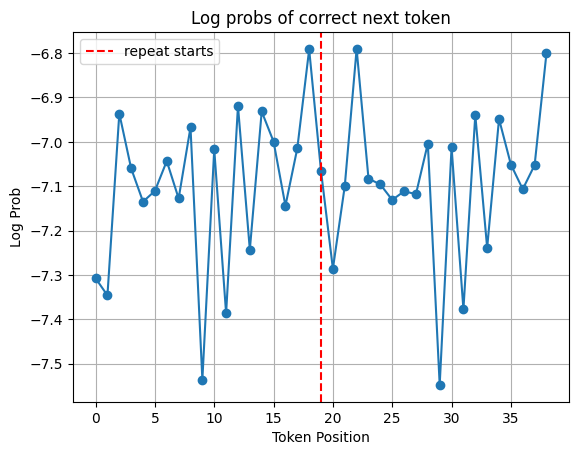

In [31]:
# plot correct token log probs

# Get correct next-token indices
target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
log_probs = t.log_softmax(output_logits, dim=-1)
log_probs = log_probs[:, :-1]  # (batch, 2*seq_len-1, vocab_size)

# Gather log probs for correct token
correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

# average across batch
correct_log_probs_av = correct_log_probs.mean(dim=0)

# Plot
plt.plot(correct_log_probs_av.cpu().numpy(), marker='o')
plt.axvline(19, color='red', linestyle='--', label='repeat starts')
plt.title("Log probs of correct next token")
plt.xlabel("Token Position")
plt.ylabel("Log Prob")
plt.legend()
plt.grid(True)
plt.show()


## Training

In [35]:
train_sequences = generate_repeated_tokens(model.vocab_size, 20, 1024)

In [36]:
# Training hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 50
BATCH_SIZE = 32  # You might need to adjust this based on your available memory

In [38]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = t.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
for epoch in range(EPOCHS):
    model.train()  # Set the model to training mode
    total_loss = 0

    for batch_idx in range(0, len(train_sequences), BATCH_SIZE):
        # Get a batch of data
        input_ids = train_sequences[batch_idx : batch_idx + BATCH_SIZE]
        targets = train_sequences[batch_idx : batch_idx + BATCH_SIZE, 1:]  # Shifted by one for next-token prediction

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask=model.maximal_causal_mask)
        logits = logits[:, :-1]  # Remove last token from logits

        # Calculate the loss
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_sequences)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

print("Training finished!")

Epoch 1/50, Loss: 0.2250
Epoch 2/50, Loss: 0.2144
Epoch 3/50, Loss: 0.2079
Epoch 4/50, Loss: 0.2003
Epoch 5/50, Loss: 0.1873
Epoch 6/50, Loss: 0.1599
Epoch 7/50, Loss: 0.1219
Epoch 8/50, Loss: 0.1003
Epoch 9/50, Loss: 0.0931
Epoch 10/50, Loss: 0.0886
Epoch 11/50, Loss: 0.0849
Epoch 12/50, Loss: 0.0815
Epoch 13/50, Loss: 0.0782
Epoch 14/50, Loss: 0.0750
Epoch 15/50, Loss: 0.0720
Epoch 16/50, Loss: 0.0694
Epoch 17/50, Loss: 0.0674
Epoch 18/50, Loss: 0.0659
Epoch 19/50, Loss: 0.0638
Epoch 20/50, Loss: 0.0610
Epoch 21/50, Loss: 0.0578
Epoch 22/50, Loss: 0.0549
Epoch 23/50, Loss: 0.0525
Epoch 24/50, Loss: 0.0504
Epoch 25/50, Loss: 0.0485
Epoch 26/50, Loss: 0.0470
Epoch 27/50, Loss: 0.0457
Epoch 28/50, Loss: 0.0437
Epoch 29/50, Loss: 0.0418
Epoch 30/50, Loss: 0.0398
Epoch 31/50, Loss: 0.0378
Epoch 32/50, Loss: 0.0361
Epoch 33/50, Loss: 0.0345
Epoch 34/50, Loss: 0.0330
Epoch 35/50, Loss: 0.0313
Epoch 36/50, Loss: 0.0298
Epoch 37/50, Loss: 0.0285
Epoch 38/50, Loss: 0.0273
Epoch 39/50, Loss: 0.

## Testing

In [40]:
test_sequences.shape

torch.Size([1024, 60])

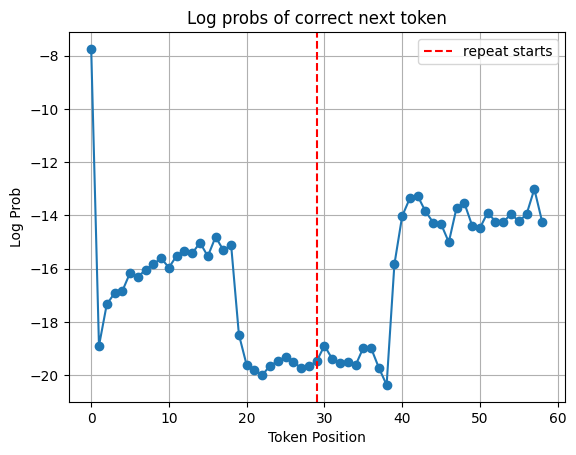

In [41]:
# generate test data
seq_len = 30
test_sequences = generate_repeated_tokens(model.vocab_size, seq_len, 1024)

# run model on test data
with t.no_grad():
    output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask)

# Get correct next-token indices
target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
log_probs = t.log_softmax(output_logits, dim=-1)
log_probs = log_probs[:, :-1]  # (batch, 2*seq_len-1, vocab_size)

# Gather log probs for correct token
correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

# average across batch
correct_log_probs_av = correct_log_probs.mean(dim=0)

# Plot
plt.plot(correct_log_probs_av.cpu().numpy(), marker='o')
plt.axvline(seq_len-1, color='red', linestyle='--', label='repeat starts')
plt.title("Log probs of correct next token")
plt.xlabel("Token Position")
plt.ylabel("Log Prob")
plt.legend()
plt.grid(True)
plt.show()


Explanation: the model was trained to repeat length 20 random sequences. So, after it sees the first 20, it tries to copy the initial sequence for tokens 20-40 ish, leading to the performance drop we see above

## Induction head transformer with manually set weights

In [43]:
manual_model = SimpleTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)
manual_model.to(DEVICE)


SimpleTransformer(
  (token_embedding): Embedding(20, 128)
  (positional_embedding): Embedding(64, 128)
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (W_q): Linear(in_features=128, out_features=128, bias=False)
      (W_k): Linear(in_features=128, out_features=128, bias=False)
      (W_v): Linear(in_features=128, out_features=128, bias=False)
      (W_o): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (unembed): Linear(in_features=128, out_features=20, bias=False)
)

In [44]:
# need 3*VOCAB_SIZE + MAX_SEQ_LEN almost orthogonal vectors
3*VOCAB_SIZE + MAX_SEQ_LEN

124

In [55]:
while True:
    mat = t.randn(3*VOCAB_SIZE + MAX_SEQ_LEN, D_MODEL, device=DEVICE)
    if t.linalg.matrix_rank(mat) == 3*VOCAB_SIZE + MAX_SEQ_LEN:
        break
print(mat.shape)

emb_vectors, unemb_vectors, prev_token_space, pos_encs = t.split(mat, [20, 20, 20, 64], dim=0)


torch.Size([124, 128])


In [ ]:
# use these to generate 2 sets of W_q, W_k, W_v, W_o parameters
